# **1. Análisis Exploratorio de Datos Originales**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
sns.set_style("whitegrid")
plt.style.use("ggplot")
sns.set(font_scale=1.1)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Definimos las rutas donde se encuentran los datos y donde se exportarán los resultados
DATA_DIR = '/content/drive/My Drive/azucar'
OUTPUT_DIR = '/content/drive/My Drive/azucar'
data_file = os.path.join(DATA_DIR, "BD_IPSA_1940.xlsx")

# Cargamos el archivo Excel original sin procesar para realizar un análisis exploratorio
df_expl = pd.read_excel(data_file)

# Preprocesamiento inicial: se formatean los nombres de las columnas para que sean más sencillos
df_expl.columns = [col.lower().strip().replace(" ", "_").replace("%", "pct_") for col in df_expl.columns]

In [4]:
# Se muestran las primeras filas para tener una visión general del contenido del dataset
print("Primeras filas del dataset (Análisis Exploratorio):")
print(df_expl.head())

# Se imprime la información del DataFrame (tipos de datos, cantidad de valores no nulos, etc.)
print("Información del DataFrame:")
df_expl.info()

Primeras filas del dataset (Análisis Exploratorio):
   unnamed:_0          nome    faz tal         tipocorte   variedad madurada  \
0          11  AMAIME SILCA  81291  40  Mecanizado Verde  CC01-1940       SI   
1          12  AMAIME SILCA  81291  41  Mecanizado Verde  CC01-1940       SI   
2          13  AMAIME SILCA  81291  41  Mecanizado Verde  CC01-1940       SI   
3          15  AMAIME SILCA  81291  43  Mecanizado Verde  CC01-1940       SI   
4          16  AMAIME SILCA  81291  43  Mecanizado Verde  CC01-1940       SI   

                             producto  dosismad  semsmad  ...  cortes    me  \
0  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      8.3  ...       4  12.7   
1  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      6.3  ...       2   7.8   
2  BONUS 250 EC REGULADOR FISIOLÓGICO       0.6      7.9  ...       3   8.8   
3  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      6.6  ...       1   6.1   
4  BONUS 250 EC REGULADOR FISIOLÓGICO       0.6      8.1  ...       2   

**Contexto del Proceso y Variables**


- **unnamed:_0, nome, faz, tal:**  
  Son índices y etiquetas identificativas de la finca o área; no aportan información predictiva sobre la calidad o productividad de la caña.

- **tipocorte:**  
  Indica el método de corte (manual o mecánico). Puede afectar la preservación de la sacarosa, pero si su variabilidad es baja, se descarta.

- **variedad y madurada:**  
  La variedad influye en el potencial de azúcar y “madurada” señala si la caña alcanzó su madurez. Son relevantes para entender diferencias en calidad.

- **producto:**  
  Refiere al insumo aplicado (por ejemplo, regulador), que impacta la maduración. Su efecto suele analizarse junto con dosis y tiempo.

- **dosismad y semsmad:**  
  Indican la dosis y las semanas desde la aplicación del insumo, respectivamente, fundamentales para la maduración y acumulación de sacarosa.

- **edad y cortes:**  
  La edad del cultivo y el número de recolecciones afectan tanto la calidad (sacarosa) como la productividad (TCH).

- **me:**  
  No tenemos claridad (podría ser materia extraña u otro indicador)

- **vejez:**  
  Refleja el envejecimiento del cultivo, lo cual influye en la acumulación de sacarosa.

- **mes y periodo:**  
  Permiten relacionar la cosecha con factores estacionales. Si “periodo” resulta redundante con “mes”, se descarta.

- **lluvias:**  
  Es esencial, ya que la precipitación afecta el crecimiento y la maduración.

- **grupo_tenencia:**  
  Aunque refleja la propiedad o manejo del terreno, su impacto directo es menor y puede omitirse.

- **pct_diatrea:**  
  Mide la infestación de la plaga Diatraea, importante por su impacto negativo en la calidad y productividad.


- **Sacarosa:**
Es un indicador clave de la calidad del producto, ya que el porcentaje de sacarosa en la caña determina la cantidad de azúcar que se puede extraer. En el ingenio, después de la molienda y clarificación, se cristaliza y se separa el azúcar de la melaza. La clasificación en categorías (bajo, normal, alto) permite evaluar si la caña está en un estado óptimo para la producción de azúcar.

- **TCH (Toneladas de Caña por Hectárea):**
Esta variable mide la productividad del cultivo. Dado que la caña se cultiva durante varios meses y su producción depende de factores como clima, riego, fertilización y manejo agronómico, clasificar la TCH en rangos (bajo, normal, alto) ayuda a identificar áreas de mejora o prácticas exitosas en el cultivo.

In [5]:
# Se imprime un resumen estadístico de las variables numéricas (media, desviación estándar, etc.)
print("Resumen Estadístico de Variables Numéricas:")
print(df_expl.describe())

Resumen Estadístico de Variables Numéricas:
        unnamed:_0           faz     dosismad      semsmad         edad  \
count  2187.000000   2187.000000  2187.000000  2187.000000  2187.000000   
mean   2126.506630  80588.332876     0.993278     9.164838    12.766118   
std    1228.561661    572.818299     0.309096     3.441579     1.117866   
min      11.000000  80100.000000     0.000000    -1.600000    10.300000   
25%    1038.000000  80222.000000     0.800000     7.100000    12.000000   
50%    2219.000000  80396.000000     1.000000     8.700000    12.500000   
75%    3223.500000  80660.000000     1.200000    10.600000    13.300000   
max    4222.000000  82519.000000     9.000000    45.000000    21.100000   

            cortes           me        vejez     sacarosa          mes  \
count  2187.000000  2187.000000  2187.000000  2187.000000  2187.000000   
mean      2.794239     9.197759     4.172154    12.777732     6.758573   
std       1.621195     1.574409     6.339255     0.854397 

In [6]:
# Identificamos y listamos las columnas numéricas y categóricas para posteriores análisis
numeric_columns = df_expl.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df_expl.select_dtypes(include=['object']).columns.tolist()
print("\nVariables numéricas:", numeric_columns)
print("Variables categóricas:", categorical_columns)


Variables numéricas: ['unnamed:_0', 'faz', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'sacarosa', 'mes', 'periodo', 'tch', 'lluvias', 'grupo_tenencia', 'pct_diatrea']
Variables categóricas: ['nome', 'tal', 'tipocorte', 'variedad', 'madurada', 'producto']


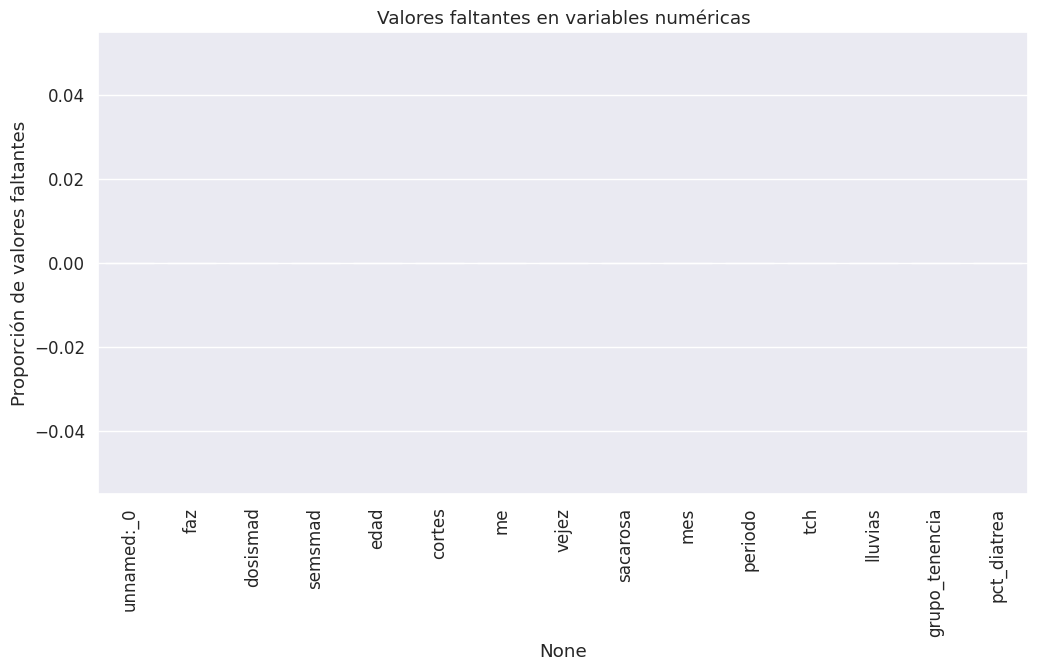

In [7]:
# Graficamos la proporción de valores faltantes en las variables numéricas para identificar posibles problemas
missing_numeric = df_expl[numeric_columns].isnull().mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_numeric.index, y=missing_numeric.values, color='red')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Valores faltantes en variables numéricas")
plt.show()

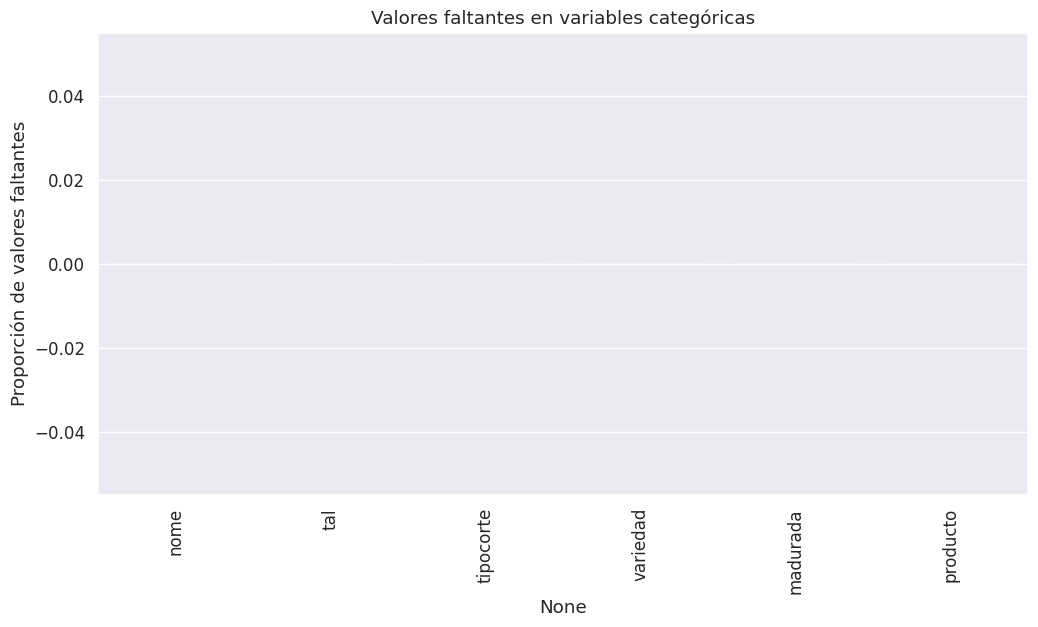

In [8]:
# Hacemos lo mismo para las variables categóricas
missing_categorical = df_expl[categorical_columns].isnull().mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_categorical.index, y=missing_categorical.values, color='blue')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Valores faltantes en variables categóricas")
plt.show()

Vemos que no hay valores nulos

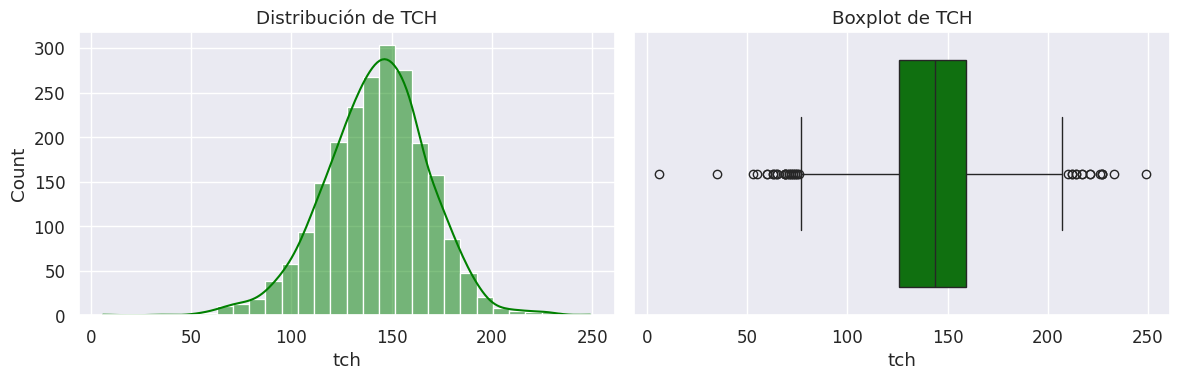

In [9]:
# Visualizamos la distribución y detección de outliers para la variable TCH (Total de Clorofilas o similar)
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df_expl['tch'], bins=30, kde=True, color='green')
plt.title("Distribución de TCH")
plt.subplot(1,2,2)
sns.boxplot(x=df_expl['tch'], color='green')
plt.title("Boxplot de TCH")
plt.tight_layout()
plt.show()

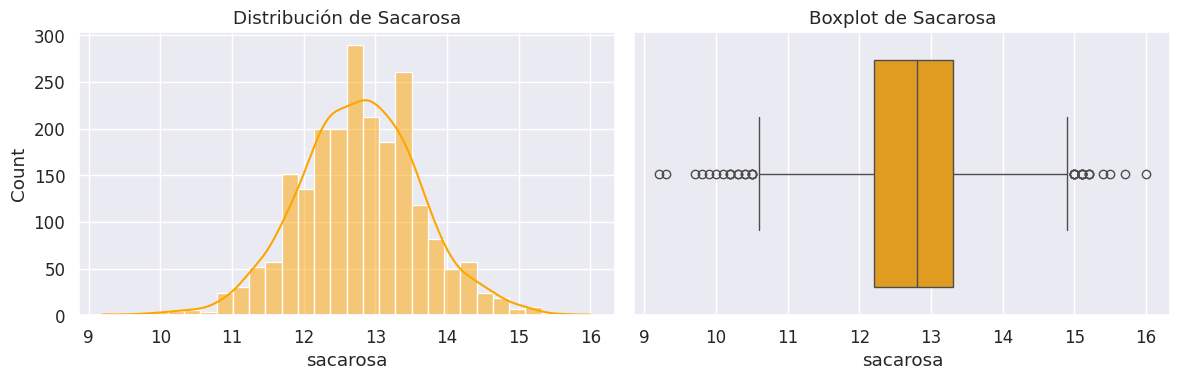

In [10]:

# Repetimos la visualización para la variable Sacarosa
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df_expl['sacarosa'], bins=30, kde=True, color='orange')
plt.title("Distribución de Sacarosa")
plt.subplot(1,2,2)
sns.boxplot(x=df_expl['sacarosa'], color='orange')
plt.title("Boxplot de Sacarosa")
plt.tight_layout()
plt.show()

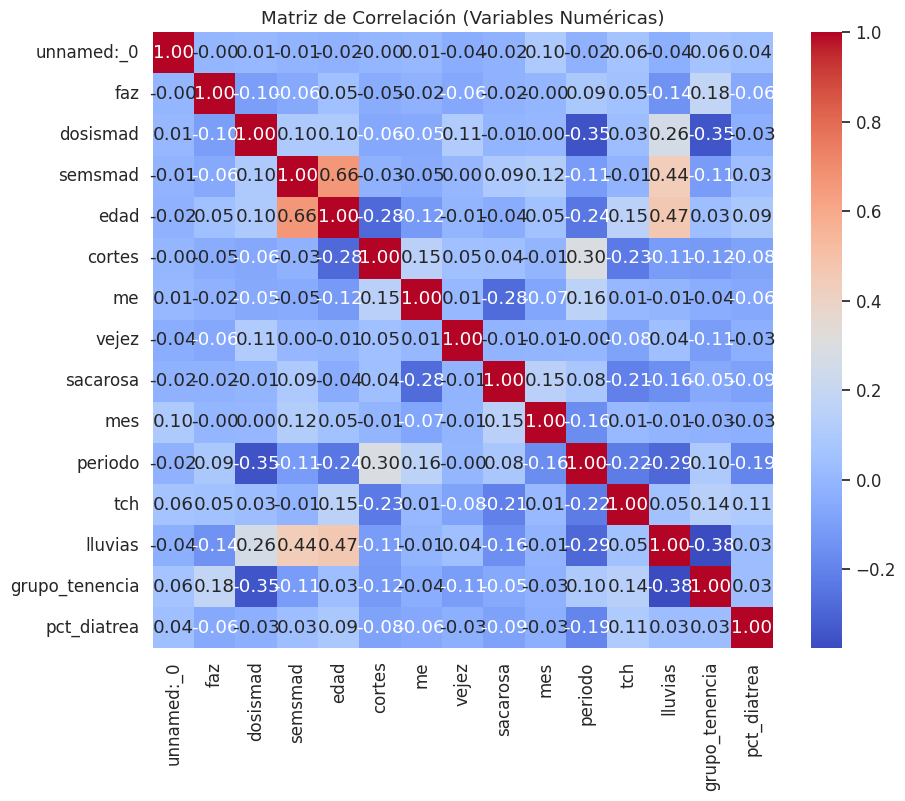

In [11]:
# Creamos una matriz de correlación entre las variables numéricas para identificar relaciones lineales fuertes o débiles.
numeric_cols = df_expl.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_expl[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()

Aquí tenemos un conjunto de observaciones de la matriz de correlación:

- La columna **unnamed:_0** muestra prácticamente nula correlación con el resto, lo que confirma que es solo un índice sin información útil.  
- Las variables identificativas como **faz** presentan correlaciones muy bajas, lo que refuerza su carácter meramente descriptivo sin impacto en el proceso productivo.  
- Notamos una correlación moderada (≈0.66) entre **semsmad** (semanas desde la aplicación del madurante) y **edad** del cultivo. Esto sugiere que los cultivos de mayor edad tienden a esperar más tiempo tras la aplicación del producto, lo que puede ser clave para lograr una maduración óptima y, por ende, un mayor contenido de sacarosa.  
- **Lluvias** se correlaciona moderadamente con **edad** (0.47) y con **semsmad** (0.44), lo que indica que en condiciones de mayor precipitación los cultivos pueden tener una maduración distinta, afectando tanto la calidad (sacarosa) como la productividad.  
- Se observa una correlación negativa entre **tch** (productividad en toneladas por hectárea) y **sacarosa** (-0.21), lo cual es consistente con el conocido compromiso entre rendimiento y calidad: a medida que aumenta la producción, puede disminuir ligeramente la concentración de azúcar.  
- Otros parámetros, como **dosismad**, tienen correlaciones bajas o moderadas con algunas variables (por ejemplo, una correlación negativa moderada con **periodo** de -0.35), lo que podría reflejar diferencias en las estrategias de aplicación de insumos según el ciclo de cultivo o condiciones específicas del terreno (por ejemplo, influencias relacionadas con la tenencia).


En general la matriz indica que las variables directamente relacionadas con el manejo del cultivo (edad, semsmad, lluvias) tienen relaciones moderadas entre sí, lo que respalda su relevancia para explicar tanto la calidad (sacarosa) como la productividad (tch). Por otro lado, las variables de identificación y algunas ambiguas (como el índice unnamed) no muestran correlaciones significativas, lo que justifica su exclusión en el modelado predictivo.

# **2. Preprocesamiento Avanzado: Selección de columnas, limpieza de outliers y creación de variables**

In [12]:
# Cargamos nuevamente el dataset (se parte del mismo archivo) y se aplican técnicas de limpieza.
data_file_adv = os.path.join(DATA_DIR, "BD_IPSA_1940.xlsx")
df_base = pd.read_excel(data_file_adv)

# Se formatean los nombres de las columnas para tener consistencia y facilitar el manejo.
df_base.columns = [
    x.lower().strip().replace(" ", "_").replace(".", "_").replace("-", "_")
    .replace("(", "").replace(")", "").replace("%", "pct_")
    for x in df_base.columns
]

In [13]:
# Seleccionamos únicamente las columnas relevantes para el análisis y la modelización.
columns_to_keep = ["dosismad", "semsmad", "edad", "cortes", "sacarosa", "tch", "lluvias", "pct_diatrea", "mes", "me", "grupo_tenencia"]
df = df_base[columns_to_keep]

# Imprimimos la cantidad de valores nulos por columna para evaluar la calidad de los datos.
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
dosismad          0
semsmad           0
edad              0
cortes            0
sacarosa          0
tch               0
lluvias           0
pct_diatrea       0
mes               0
me                0
grupo_tenencia    0
dtype: int64


In [14]:
# Convertimos las columnas 'mes' y 'grupo_tenencia' a variables categóricas y aplicamos One-Hot Encoding.
columnas_OneHot = {'mes', 'grupo_tenencia'}
if columnas_OneHot.issubset(df.columns):
    df[list(columnas_OneHot)] = df[list(columnas_OneHot)].astype('category')
    df = pd.get_dummies(df, columns=['mes', 'grupo_tenencia'], drop_first=True)
    print("Nuevas columnas luego del one-hot encoding:")
    print(df.columns)

Nuevas columnas luego del one-hot encoding:
Index(['dosismad', 'semsmad', 'edad', 'cortes', 'sacarosa', 'tch', 'lluvias',
       'pct_diatrea', 'me', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6',
       'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12',
       'grupo_tenencia_2', 'grupo_tenencia_3'],
      dtype='object')


<ipython-input-14-e5454f6d38e7>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[list(columnas_OneHot)] = df[list(columnas_OneHot)].astype('category')


<Figure size 1200x600 with 0 Axes>

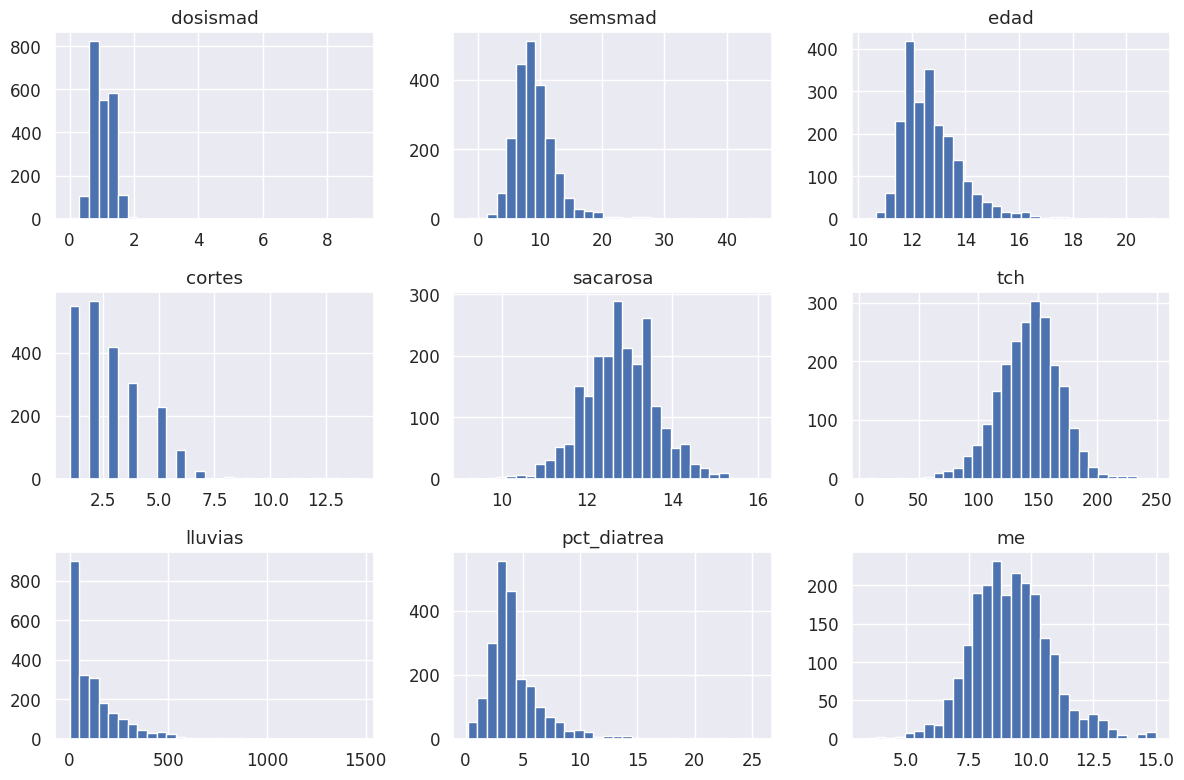

In [15]:
# Visualizamos distribuciones de todas las variables mediante histogramas para tener una visión global.
plt.figure(figsize=(12, 6))
df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [16]:
# Se calculan percentiles para TCH y Sacarosa, de modo de conocer los rangos y detectar posibles outliers.
percentiles = [0, 5, 10, 25, 50, 75, 90, 95, 100]
percentile_values = df[['sacarosa', 'tch']].quantile([p/100 for p in percentiles])
print("Percentiles para TCH y Sacarosa:")
print(percentile_values)

Percentiles para TCH y Sacarosa:
      sacarosa    tch
0.00       9.2    6.0
0.05      11.4   99.0
0.10      11.7  110.0
0.25      12.2  126.0
0.50      12.8  144.0
0.75      13.3  159.0
0.90      13.8  174.0
0.95      14.2  182.7
1.00      16.0  249.0


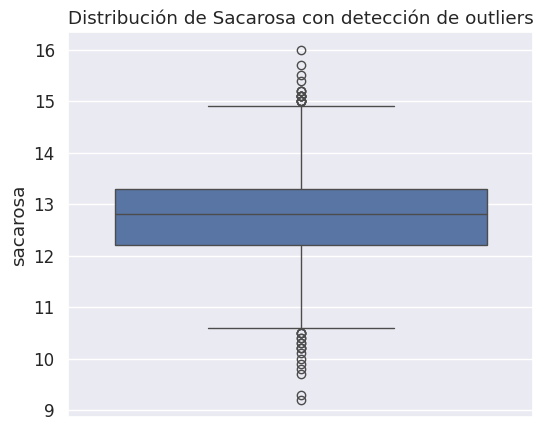

In [17]:
# Se muestran boxplots de Sacarosa y TCH para visualizar visualmente la presencia de outliers.
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['sacarosa'])
plt.title("Distribución de Sacarosa con detección de outliers")
plt.show()

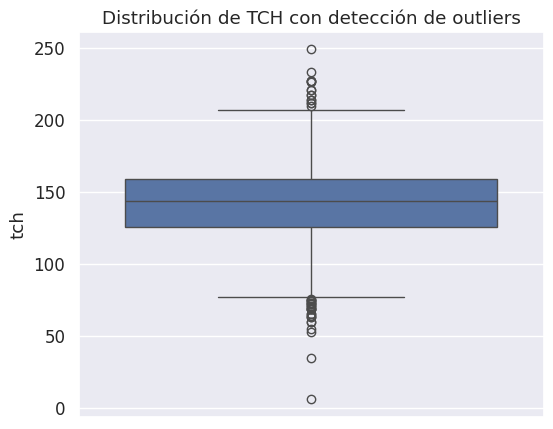

In [18]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['tch'])
plt.title("Distribución de TCH con detección de outliers")
plt.show()

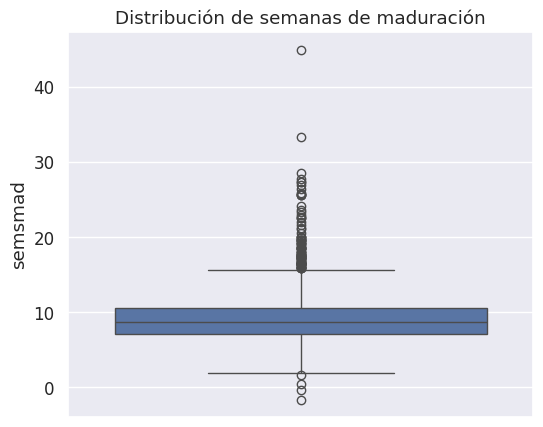

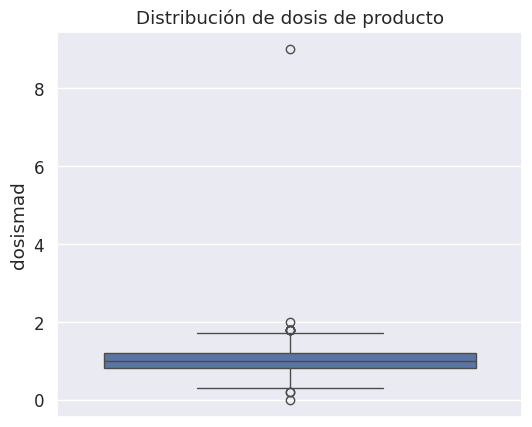

In [19]:
# También se revisan otras variables relevantes, como semsmad y dosismad, mediante boxplots.
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['semsmad'])
plt.title("Distribución de semanas de maduración")
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(y=df['dosismad'])
plt.title("Distribución de dosis de producto")
plt.show()

In [20]:
# Se aplican reglas para eliminar outliers basados en conocimientos del dominio:
#   - Para semsmad: se conservan valores entre 5 y 14.84.
#   - Para TCH: se conservan valores entre 40 y 182.
#   - Para cortes: se conserva hasta 8 cortes (valor máximo aceptado).
#   - Para dosismad: se conservan valores mayores a 0 y menores o iguales a 1.5.
df = df[(df['semsmad'] >= 5) & (df['semsmad'] <= 14.84)]
df = df[(df['tch'] <= 182) & (df['tch'] >= 40)]
df = df[(df['cortes'] <= 8)]
df = df[(df['dosismad'] > 0) & (df['dosismad'] <= 1.5)]

In [21]:
# Se verifica nuevamente la cantidad de outliers en TCH y Sacarosa utilizando el método IQR.
for col in ['sacarosa', 'tch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Número de outliers en {col}: {len(outliers)}")

Número de outliers en sacarosa: 24
Número de outliers en tch: 21


In [22]:
# Se crean variables categóricas para TCH y Sacarosa utilizando cortes dados por el contexto del problema.
# Se definen tres categorías: 'bajo', 'normal' y 'alto' basadas en los intervalos de corte.
df['tch_category'] = pd.cut(df['tch'], bins=[-float('inf'), 126, 159, float('inf')], labels=['bajo', 'normal', 'alto'])
df['sacarosa_category'] = pd.cut(df['sacarosa'], bins=[-float('inf'), 12.2, 13.3, float('inf')], labels=['bajo', 'normal', 'alto'])

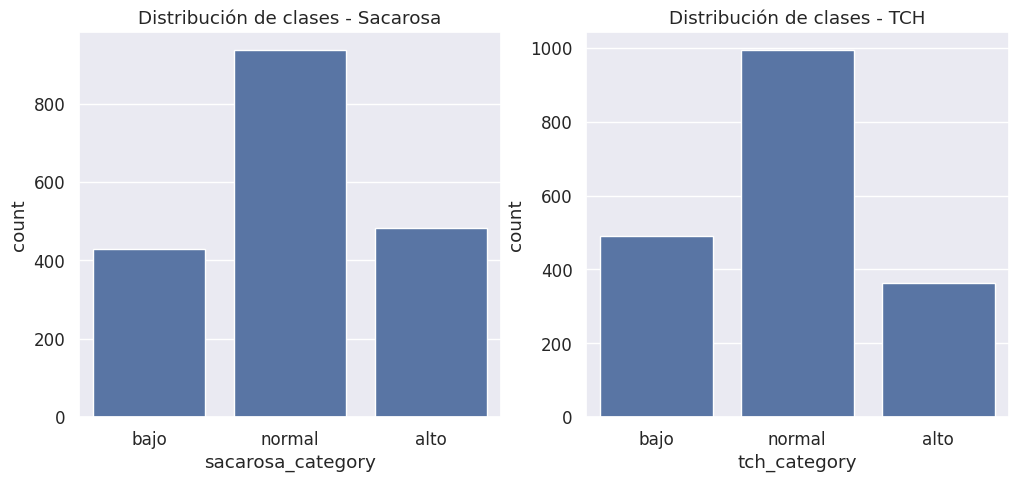

In [23]:
# Se visualiza la distribución de clases para las variables categóricas creadas mediante gráficos de barras.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=df['sacarosa_category'], order=['bajo','normal','alto'], ax=axes[0])
axes[0].set_title('Distribución de clases - Sacarosa')
sns.countplot(x=df['tch_category'], order=['bajo','normal','alto'], ax=axes[1])
axes[1].set_title('Distribución de clases - TCH')
plt.show()

# **3. Modelado y Optimización**

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

In [26]:
# Se define una validación cruzada estratificada (StratifiedKFold) para mantener la distribución de clases.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [30]:
# Lista de targets y sus nombres descriptivos para iterar en ambos casos
y_sacarosa = df["sacarosa_category"]
y_TCH = df["tch_category"]
targets = [(y_sacarosa, "Sacarosa"), (y_TCH, "TCH")]

X = df.drop(columns=["sacarosa", "tch", "sacarosa_category", "tch_category"])

## **3.1 Modelado Base**

In [25]:
# Se arma un pipeline que primero escala las variables y luego aplica Regresión Logística
pipeline_lr_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000))
])

In [31]:
for y_target, target_name in targets:
    print("\n========================================================")
    print(f"Modelo Base SIN optimización para target: {target_name}")
    print("========================================================")

    # A) Regresión Logística Base
    # Se arma un pipeline que escala las variables y aplica Regresión Logística con parámetros fijos
    pipeline_lr_base = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000))
    ])

    # Se realizan las predicciones usando validación cruzada
    y_pred_lr_base = cross_val_predict(pipeline_lr_base, X, y_target, cv=cv)

    print(f"\n----- Regresión Logística Base para {target_name} -----")
    print(f"Accuracy: {accuracy_score(y_target, y_pred_lr_base):.4f}")
    print(f"Precisión: {precision_score(y_target, y_pred_lr_base, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_target, y_pred_lr_base, average='macro'):.4f}")
    print(f"F1-score: {f1_score(y_target, y_pred_lr_base, average='macro'):.4f}")
    print("\nReporte de clasificación:\n", classification_report(y_target, y_pred_lr_base))

    # B) KNN Base
    # Se arma un pipeline que escala las variables y aplica KNN con un valor fijo de k = 5
    pipeline_knn_base = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    # Se realizan las predicciones utilizando validación cruzada
    y_pred_knn_base = cross_val_predict(pipeline_knn_base, X, y_target, cv=cv)

    print(f"\n----- KNN Base para {target_name} -----")
    print(f"Accuracy: {accuracy_score(y_target, y_pred_knn_base):.4f}")
    print(f"Precisión: {precision_score(y_target, y_pred_knn_base, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_target, y_pred_knn_base, average='macro'):.4f}")
    print(f"F1-score: {f1_score(y_target, y_pred_knn_base, average='macro'):.4f}")
    print("\nReporte de clasificación:\n", classification_report(y_target, y_pred_knn_base))


Modelo Base SIN optimización para target: Sacarosa

----- Regresión Logística Base para Sacarosa -----
Accuracy: 0.5517
Precisión: 0.5550
Recall: 0.4760
F1-score: 0.4888

Reporte de clasificación:
               precision    recall  f1-score   support

        alto       0.54      0.39      0.45       482
        bajo       0.57      0.28      0.37       429
      normal       0.55      0.76      0.64       936

    accuracy                           0.55      1847
   macro avg       0.55      0.48      0.49      1847
weighted avg       0.55      0.55      0.53      1847


----- KNN Base para Sacarosa -----
Accuracy: 0.5420
Precisión: 0.5273
Recall: 0.5195
F1-score: 0.5211

Reporte de clasificación:
               precision    recall  f1-score   support

        alto       0.50      0.56      0.53       482
        bajo       0.50      0.40      0.45       429
      normal       0.58      0.60      0.59       936

    accuracy                           0.54      1847
   macro avg     

## **3.2 Optimización de Hiperparámetros**

### **A) Búsqueda en Malla (GridSearchCV)**

In [32]:
for y_target, target_name in targets:
    print("\n========================================================")
    print(f"GridSearchCV para target: {target_name}")
    print("========================================================")

    # 1. Optimización de KNN con GridSearchCV
    pipeline_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])
    param_grid_knn = {
        'knn__n_neighbors': list(range(1, 31)),  # Evaluar valores de 1 a 30 vecinos
        'knn__weights': ['uniform', 'distance']
    }
    grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=cv, scoring='accuracy', n_jobs=-1)
    grid_search_knn.fit(X, y_target)

    print(f"\n----- GridSearchCV - KNN para {target_name} -----")
    print("Mejores hiperparámetros:", grid_search_knn.best_params_)
    print("Mejor accuracy:", grid_search_knn.best_score_)

    # 2. Optimización de Regresión Logística con GridSearchCV
    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))
    ])
    param_grid_lr = {
        'lr__C': np.logspace(-4, 4, 10)  # Busca valores de C en escala logarítmica
    }
    grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=cv, scoring='accuracy', n_jobs=-1)
    grid_search_lr.fit(X, y_target)

    print(f"\n----- GridSearchCV - Regresión Logística para {target_name} -----")
    print("Mejores hiperparámetros:", grid_search_lr.best_params_)
    print("Mejor accuracy:", grid_search_lr.best_score_)


GridSearchCV para target: Sacarosa

----- GridSearchCV - KNN para Sacarosa -----
Mejores hiperparámetros: {'knn__n_neighbors': 10, 'knn__weights': 'distance'}
Mejor accuracy: 0.5744451768842013

----- GridSearchCV - Regresión Logística para Sacarosa -----
Mejores hiperparámetros: {'lr__C': np.float64(0.3593813663804626)}
Mejor accuracy: 0.5544114846553871

GridSearchCV para target: TCH

----- GridSearchCV - KNN para TCH -----
Mejores hiperparámetros: {'knn__n_neighbors': 25, 'knn__weights': 'distance'}
Mejor accuracy: 0.5598227495788471

----- GridSearchCV - Regresión Logística para TCH -----
Mejores hiperparámetros: {'lr__C': np.float64(0.005994842503189409)}
Mejor accuracy: 0.5381703654874387


### **B) Optimización Bayesiana (BayesSearchCV)**

In [34]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.1 MB/s eta 0:00:00


In [35]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real

for y_target, target_name in targets:
    print("\n========================================================")
    print(f"BayesSearchCV para target: {target_name}")
    print("========================================================")

    # 1. Optimización de KNN con BayesSearchCV
    pipeline_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])
    param_space_knn = {
        'knn__n_neighbors': Integer(1, 30),
        'knn__weights': Categorical(['uniform', 'distance'])
    }
    bayes_search_knn = BayesSearchCV(
        pipeline_knn,
        param_space_knn,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        n_iter=32,
        random_state=42
    )
    bayes_search_knn.fit(X, y_target)

    print(f"\n----- BayesSearchCV - KNN para {target_name} -----")
    print("Mejores hiperparámetros:", bayes_search_knn.best_params_)
    print("Mejor accuracy:", bayes_search_knn.best_score_)

    # 2. Optimización de Regresión Logística con BayesSearchCV
    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))
    ])
    param_space_lr = {
        'lr__C': Real(1e-4, 1e4, prior='log-uniform')
    }
    bayes_search_lr = BayesSearchCV(
        pipeline_lr,
        param_space_lr,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        n_iter=32,
        random_state=42
    )
    bayes_search_lr.fit(X, y_target)

    print(f"\n----- BayesSearchCV - Regresión Logística para {target_name} -----")
    print("Mejores hiperparámetros:", bayes_search_lr.best_params_)
    print("Mejor accuracy:", bayes_search_lr.best_score_)


BayesSearchCV para target: Sacarosa


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(13), np.str_('distance')] before, using random point [np.int64(24), 'distance']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(11), np.str_('distance')] before, using random point [np.int64(12), 'uniform']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(11), np.str_('distance')] before, using random point [np.int64(5), 'distance']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(13), np.str_('distance')] before, using random point [np.int64(19), 'uniform']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/opt


----- BayesSearchCV - KNN para Sacarosa -----
Mejores hiperparámetros: OrderedDict([('knn__n_neighbors', 13), ('knn__weights', 'distance')])
Mejor accuracy: 0.5744378524866329

----- BayesSearchCV - Regresión Logística para Sacarosa -----
Mejores hiperparámetros: OrderedDict([('lr__C', 0.2176006355186443)])
Mejor accuracy: 0.5554925657364682

BayesSearchCV para target: TCH


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(25), np.str_('distance')] before, using random point [np.int64(19), 'uniform']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(30), np.str_('distance')] before, using random point [np.int64(9), 'distance']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(30), np.str_('distance')] before, using random point [np.int64(18), 'uniform']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(30), np.str_('distance')] before, using random point [np.int64(13), 'distance']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/opt


----- BayesSearchCV - KNN para TCH -----
Mejores hiperparámetros: OrderedDict([('knn__n_neighbors', 25), ('knn__weights', 'distance')])
Mejor accuracy: 0.5598227495788471

----- BayesSearchCV - Regresión Logística para TCH -----
Mejores hiperparámetros: OrderedDict([('lr__C', 0.06972922090401662)])
Mejor accuracy: 0.5397978466271149


# **Conclusiones**

## **Resultados y Análisis de los Modelos**

1. **Modelos Base (Sin Optimización):**

   - **Para Sacarosa:**  
     - **Regresión Logística Base:** Accuracy de ~55.2% y desempeño variable entre clases, con la categoría "normal" mejor clasificada (f1-score de 0.64) y desempeño menor para "alto" y "bajo".  
     - **KNN Base (k=5):** Similar desempeño con accuracy de ~54.2% y dificultades para clasificar consistentemente las clases extremas.
     
     **Interpretación:**  
     Los modelos base indican que, sin optimización, la capacidad para distinguir correctamente entre cañas con porcentajes de sacarosa muy altos o muy bajos es limitada. Esto es crítico en el contexto de la producción de azúcar, ya que se requiere identificar cañas óptimas para el proceso y optimizar el aprovechamiento del producto.

   - **Para TCH:**  
     - **Regresión Logística Base:** Accuracy de ~52.8% con métricas muy bajas (f1-score ~0.31), lo que sugiere que el modelo tiene serias dificultades para predecir la productividad en las clases "alto" y "bajo".  
     - **KNN Base (k=5):** Accuracy de ~48.9%, indicando un desempeño aún peor.
     
     **Interpretación:**  
     La baja precisión en la clasificación de TCH puede reflejar la complejidad del cultivo, donde factores climáticos, manejo del suelo y prácticas agronómicas influyen fuertemente. La dificultad para predecir correctamente la productividad afecta la planificación agronómica y la asignación de recursos en el campo.

2. **Optimización mediante GridSearchCV y BayesSearchCV:**

   - **Para Sacarosa:**
     - **KNN Optimizado:**  
       - GridSearchCV encontró _n_neighbors=10_ y _weights="distance"_ (accuracy ≈ 57.44%).  
       - BayesSearchCV obtuvo parámetros similares (_n_neighbors≈13_, _weights="distance"_) con resultados muy cercanos.
     - **Regresión Logística Optimizada:**  
       - Se encontró un valor óptimo para _C_ (alrededor de 0.36 o 0.22) que mejora marginalmente la accuracy (≈55.4–55.5%).
     
     **Interpretación:**  
     La optimización de KNN mejora de forma más notable el desempeño, lo que sugiere que al considerar la distancia de cada vecino se capturan matices importantes en los niveles de sacarosa. La mejora en la regresión logística es menor, lo que podría indicar que la relación lineal entre las variables predictoras y la calidad de la caña (en términos de sacarosa) es compleja y quizá no se modela de forma óptima con una regresión lineal penalizada.
   
   - **Para TCH:**
     - **KNN Optimizado:**  
       - Se encontró que _n_neighbors=25_ y _weights="distance"_ mejoran la accuracy a ~56% (desde ~48.9% base).  
     - **Regresión Logística Optimizada:**  
       - El mejor valor de _C_ es muy bajo (alrededor de 0.006 o 0.07), elevando la accuracy a ~53.8–53.9%.
     
     **Interpretación:**  
     Para la productividad (TCH), el modelo KNN optimizado muestra una mejora significativa, lo que indica que la similitud entre parcelas o cultivos (capturada mediante vecinos y ponderación por distancia) es relevante. La regresión logística, aunque mejora, sigue teniendo dificultades para predecir adecuadamente las clases extremas de productividad, probablemente debido a la influencia de múltiples factores agronómicos y ambientales.





## **Conclusiones en el Contexto del Cultivo de Caña y la Producción de Azúcar**

- **Identificación de Calidad y Productividad:**  
  Dado que el porcentaje de sacarosa y la TCH son indicadores críticos para el proceso de extracción y producción de azúcar, los modelos optimizados (especialmente KNN) ayudan a identificar más efectivamente las cañas con alta calidad (sacarosa) y buena productividad. Esto es fundamental para tomar decisiones en el ingenio, donde se busca maximizar la extracción de azúcar y minimizar impurezas.

- **Relevancia del Proceso Agronómico:**  
  Los resultados reflejan que, en el contexto de la caña de azúcar, factores como el manejo del cultivo, el control de plagas (por ejemplo, el porcentaje de infestación de Diatraea), y las condiciones climáticas (lluvias, temperatura, etc.) pueden estar influyendo en la variabilidad de la sacarosa y la productividad (TCH). La baja precisión en las clases "alto" y "bajo" sugiere la necesidad de integrar más información agronómica o aplicar técnicas adicionales (como re-muestreo o técnicas de balanceo) para mejorar la predicción.

- **Optimización de Modelos:**  
  La búsqueda de hiperparámetros mejora especialmente el desempeño del modelo KNN para ambos targets. En el caso de sacarosa, ajustar el número de vecinos y usar la ponderación por distancia permite captar de forma más precisa la variabilidad en la calidad del producto, mientras que para TCH, la optimización ayuda a reflejar mejor las diferencias en productividad, lo cual es vital para gestionar los insumos y prácticas agronómicas en el campo.

- **Implicaciones para el Manejo Agronómico y de Procesamiento:**  
  Un modelo con mejor desempeño en clasificar cañas de alta calidad (en términos de sacarosa) puede orientar las decisiones en el ingenio, como la selección de cañas para procesamiento, optimización de la molienda y clarificación, y ajustes en el riego o fertilización. Del mismo modo, un modelo que identifique correctamente las parcelas con alta o baja productividad (TCH) es esencial para planificar la rotación de cultivos, el riego y la aplicación de insumos.